# Statistical Learning 
 ## Image segmentation using Bayesian Decision Rule

In this work, we explore decision making using Bayesian logic for the task of image segmentation.

Discrete Cosine Transform (DCT): Approximates **sequence** into sum of **cosine** of various frequencies. DCT is related to Fourier series. 

In our case of image data, we divide the image into blocks and DCT is done to get the cosine coeffients. 

for block x(i,j):
$$
T(k_1,k_2) = 4 \sum_{k_1=0}^{N_1 - 1} \sum_{k_2=0}^{N_2 - 1} x(k_1, k_2) \cos\left( \frac{(2i + 1)k_1 \pi}{2N_1} \right) \cos\left( \frac{(2j + 1)k_2 \pi}{2N_2} \right)
$$

$T(k_1,k_2)$ relates the input to frequency band $[\frac{\pi k_1}{2N_1},\frac{\pi k_1}{2N_1}+1]\times[\frac{\pi k_2}{2N_2},\frac{\pi k_2}{2N_2}+1]$

In this work, we use 8x8 patch to get 8x8 = 64 coeffients. 




Feature selection : To select the discriminating feature, we select the second largest coefficient from the DCT vector

In [1]:
load("/MATLAB Drive/ECE 271A_Statistical_learning/homework1/TrainingSamplesDCT_8.mat")

[~,I_FG] = maxk(abs(TrainsampleDCT_FG),2,2);
[~,I_BG] = maxk(abs(TrainsampleDCT_BG),2,2);

X_cheetah = I_FG(:,end);
X_grass = I_BG(:,end);


Prior probability of finding Cheetah and grass in a picture : $P_Y \left(y\right)$


The database given is from a single image with DCT algorithmn applied using sliding window of 8x8 matrix. The number of rows in the database is proportional to area of foreground and background.


In [2]:
P_cheetah = size(X_cheetah,1)/(size(X_cheetah,1)+size(X_grass,1))

P_cheetah = 0.1919

In [3]:
P_grass = 1 - P_cheetah

P_grass = 0.8081


Making probability histogram


In [4]:
hist_cheetah = histogram(X_cheetah,'Normalization', 'probability')

hist_cheetah = 
  Histogram with properties:
             Data: [250x1 double]
           Values: [0.1560 0.1760 0.0400 0.0520 0.0680 0.0880 0.1080 0.0520 0.0080 0 0.0080 0.0480 0.0600 0.0320 0.0080 0.0120 0.0280 0.0320 0.0080 0.0040 0 0 0 0 0.0040 0 0 0 0 0.0040 0 0.0040]
          NumBins: 32
         BinEdges: [1.5000 2.5000 3.5000 4.5000 5.5000 6.5000 7.5000 8.5000 9.5000 10.5000 11.5000 12.5000 13.5000 14.5000 15.5000 16.5000 17.5000 18.5000 19.5000 20.5000 21.5000 22.5000 23.5000 24.5000 25.5000 26.5000 27.5000 28.5000 ... ] (1x33 double)
         BinWidth: 1
        BinLimits: [1.5000 33.5000]
    Normalization: 'probability'
        FaceColor: 'auto'
        EdgeColor: [0 0 0]
  Show all properties


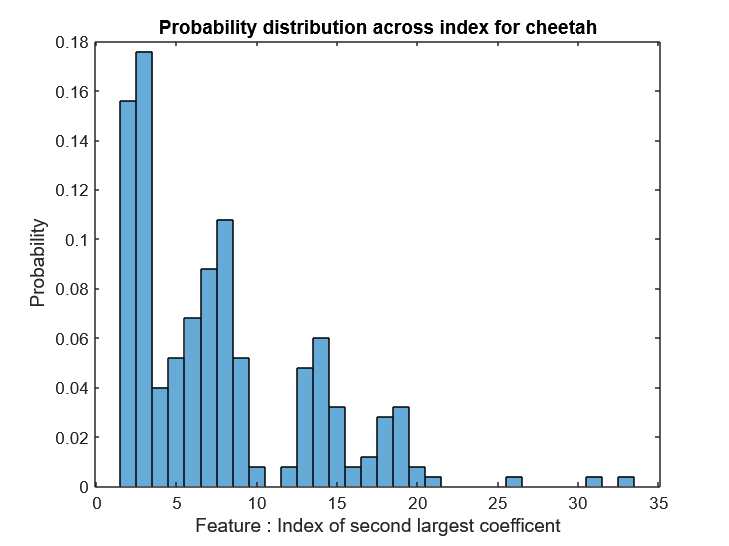

In [5]:
xlabel("Feature : Index of second largest coefficent")
ylabel("Probability")
title('Probability distribution across index for cheetah')

In [6]:
hist_grass = histogram(X_grass,'Normalization', 'probability')

hist_grass = 
  Histogram with properties:
             Data: [1053x1 double]
           Values: [0.3010 0.3960 0.0380 0.0921 0.0902 0.0171 0.0256 0.0180 0.0057 0 0.0028 0.0066 0.0028 0.0019 0 0 0.0019]
          NumBins: 17
         BinEdges: [1.5000 2.5000 3.5000 4.5000 5.5000 6.5000 7.5000 8.5000 9.5000 10.5000 11.5000 12.5000 13.5000 14.5000 15.5000 16.5000 17.5000 18.5000]
         BinWidth: 1
        BinLimits: [1.5000 18.5000]
    Normalization: 'probability'
        FaceColor: 'auto'
        EdgeColor: [0 0 0]
  Show all properties


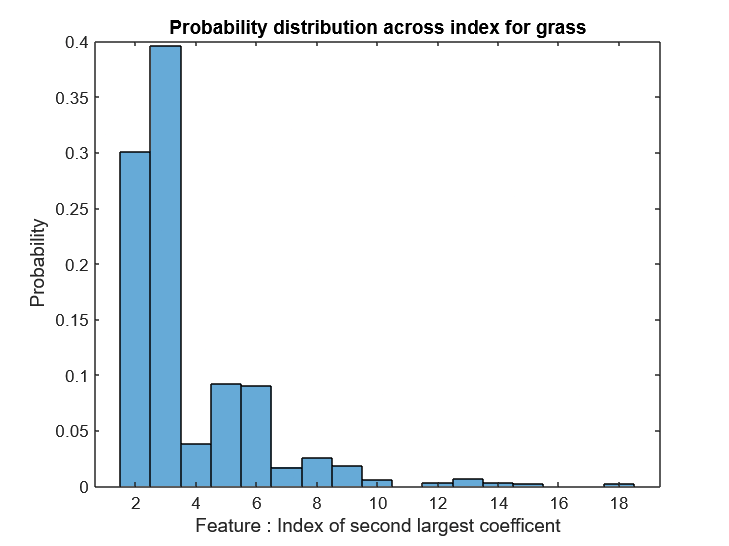

In [7]:
xlabel("Feature : Index of second largest coefficent")
ylabel("Probability")
title('Probability distribution across index for grass')


Conditional probability of the indices given the class : $P_{X|Y} (x,y)$


In [8]:
P_x_given_cheetah =(sum(X_cheetah == 1:64)/size(X_cheetah,1))';
P_x_given_grass =(sum(X_grass == 1:64)/size(X_grass,1))';


Importing and preprocessing the image



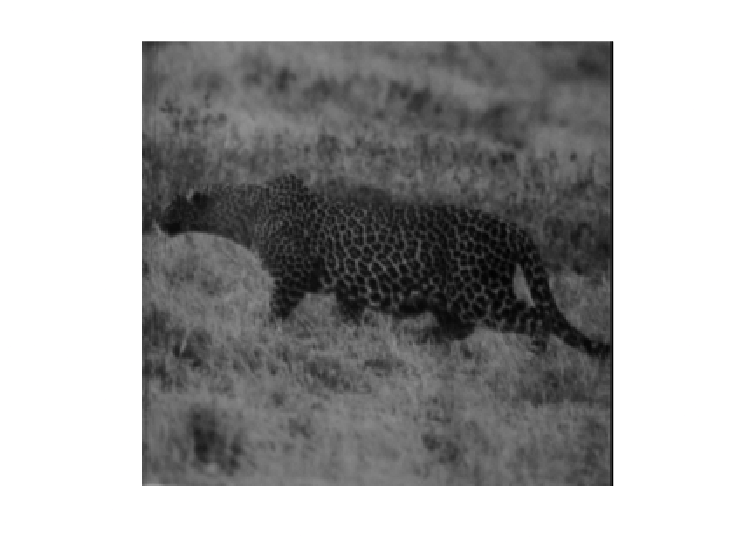

In [9]:
I = imread("cheetah.bmp");
imshow(I)


Ground truth


In [10]:
I_ground = imread("cheetah_mask.bmp");
I_ground_double = im2double(I_ground);


Padding the edges of the image for sliding window


In [11]:
image = im2double(I); %255x270
win_dim = 8; % 8x8
pad_x_dir = win_dim/2;
pad_y_dir = win_dim/2;
I_pad = padarray(image,[pad_x_dir,pad_y_dir],"replicate") % 261x278 for 8x8 window with top left filter as pixel filter.

I_pad = 263x278
    0.2392    0.2392    0.2392    0.2392    0.2392    0.2353    0.2000    0.1804    0.1843    0.1882    0.1961    0.2353    0.2235    0.2392    0.2667    0.2706    0.2706    0.2784    0.3059    0.3255    0.3451    0.3686    0.3804    0.3804    0.3843    0.3686    0.3451    0.3373    0.3412    0.3529    0.3882    0.4157    0.4431    0.4471    0.4549    0.4588    0.4706    0.4784    0.4863    0.4902    0.4863    0.4863    0.4902    0.4824    0.4745    0.4863    0.4980    0.5059    0.5176    0.5294
    0.2392    0.2392    0.2392    0.2392    0.2392    0.2353    0.2000    0.1804    0.1843    0.1882    0.1961    0.2353    0.2235    0.2392    0.2667    0.2706    0.2706    0.2784    0.3059    0.3255    0.3451    0.3686    0.3804    0.3804    0.3843    0.3686    0.3451    0.3373    0.3412    0.3529    0.3882    0.4157    0.4431    0.4471    0.4549    0.4588    0.4706    0.4784    0.4863    0.4902    0.4863    0.4863    0.4902    0.4824    0.4745    0.4863    0.4980    0.5059   


DCT matrix to array \- zig zag vector

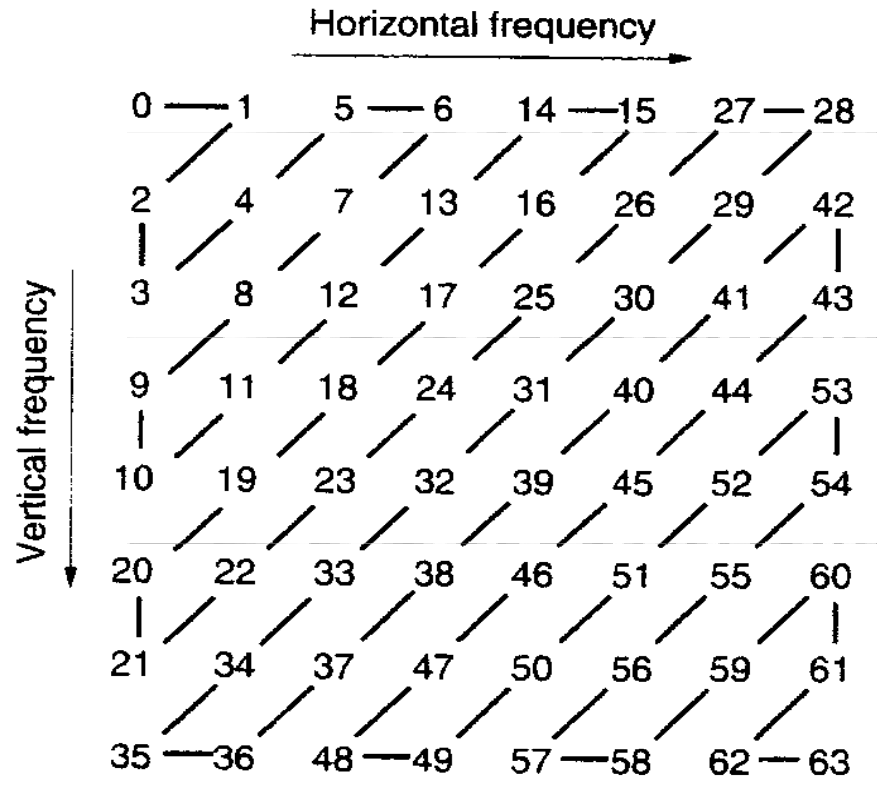


In [12]:
dct_vec_order = [1    2    6    7    15    16    28    29;
3    5    8    14    17    27    30    43;
4    9    13    18    26    31    42    44;
10    12    19    25    32    41    45    54;
11    20    24    33    40    46    53    55;
21    23    34    39    47    52    56    61;
22    35    38    48    51    57    60    62;
36    37    49    50    58    59    63    64];


Sliding window on the image and extracting the DCT matrix as array


In [13]:
k=0;
feature = ones(size(image,1)*size(image,2),win_dim*win_dim);
fl = zeros(1,win_dim*win_dim);
for i = 1:size(image,1)
    for j = 1:size(image,2)
        image_dct(i:i+win_dim-1,j:j+win_dim-1)=dct2(I_pad(i:i+win_dim-1,j:j+win_dim-1));
        k=k+1;
        fl(dct_vec_order) = image_dct(i:i+win_dim-1,j:j+win_dim-1);
        feature(k,:) = fl;
    end
end


Obtaining feature X from the flattened DCT matrix


In [14]:
[~,X] = maxk(abs(feature),2,2);
X=X(:,end);


Calculating Bayes Decision Rule for classification based on prior probabilities and


In [15]:
function [P_cheetah_given_x_prop,P_grass_given_x_prop,A] = BDR (X,P_x_given_cheetah,P_cheetah,P_x_given_grass,P_grass,factor)
    P_cheetah_given_x_prop = P_x_given_cheetah(X)*P_cheetah; % Value proportional to Probability that class is cheetah given feature x
    P_grass_given_x_prop = P_x_given_grass(X)*P_grass;          %  Value proportional to Probability that class is cheetah given feature x
    A = (P_cheetah_given_x_prop>factor*P_grass_given_x_prop); % Action - segmentation based on Bayes Decision Rule - choose class with more conditional probability given the feature to reduce risk. A factor is introduced instead of the regular 0-1 loss function
end


For 0\-1 loss function


In [16]:
factor = 1

factor = 1

In [17]:
[P_cheetah_given_x_prop,P_grass_given_x_prop,A] = BDR (X,P_x_given_cheetah,P_cheetah,P_x_given_grass,P_grass,factor);


Plotting the mask



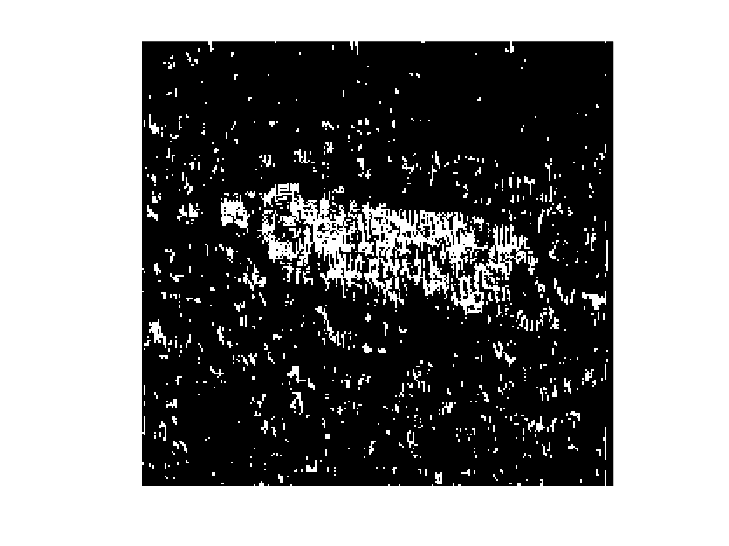

In [18]:
mask = reshape(A,size(image,2),[])';
imshow(mask)


Comparison of result with ground truth



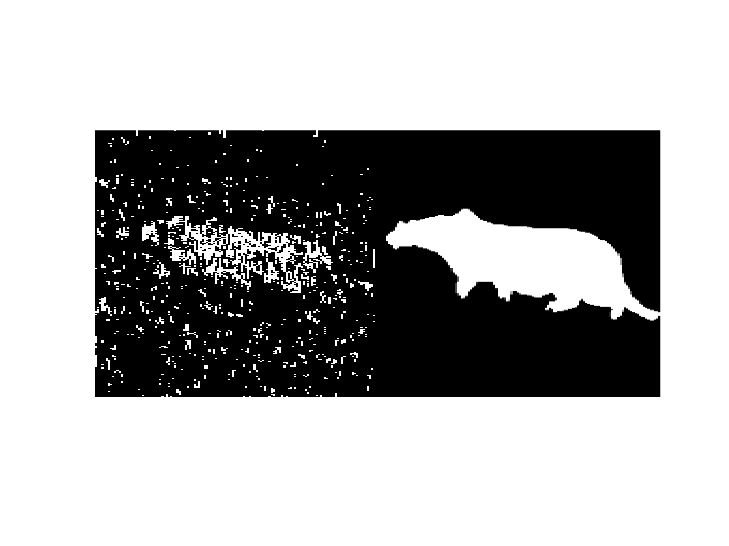

In [19]:
montage({mask,I_ground})


Probability of error of algorithmn


In [20]:
error = sum(abs(mask-I_ground_double),"all")/(size(I_ground,1)*size(I_ground,2))

error = 0.1734


For assigning different loss to different action


In [21]:
factor = 0.17

factor = 0.1700

In [22]:
[P_cheetah_given_x_prop,P_grass_given_x_prop,A] = BDR (X,P_x_given_cheetah,P_cheetah,P_x_given_grass,P_grass,factor);


Plotting the mask



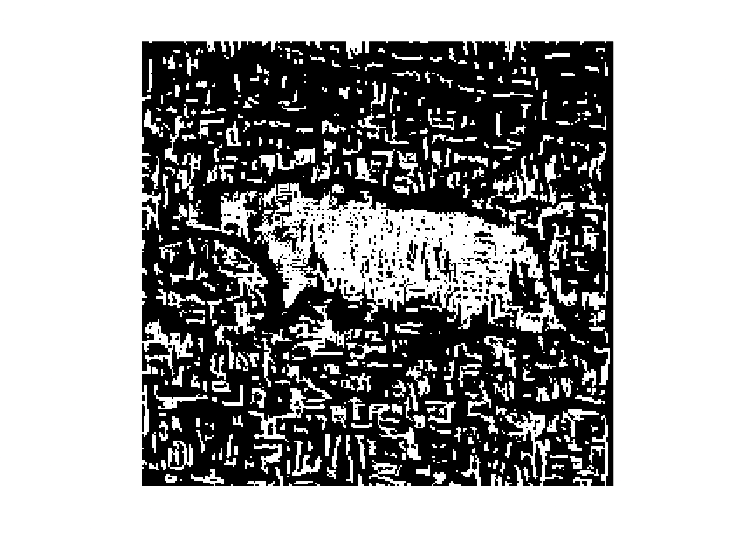

In [23]:
mask = reshape(A,size(image,2),[])';
imshow(mask)


Comparison of result with ground truth



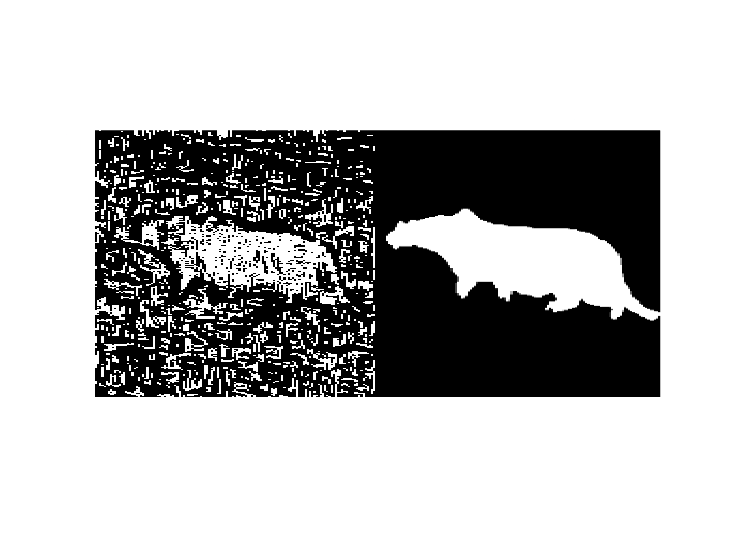

In [24]:
montage({mask,I_ground})


Probability of error of algorithmn


In [25]:
error = sum(abs(mask-I_ground_double),"all")/(size(I_ground,1)*size(I_ground,2))

error = 0.2708